# Intelligent Warehouse Robot Navigation
## D3: Implementation – Algorithms & Visualization

This notebook implements all search algorithms for the Warehouse Robot Navigation problem as defined in D1 and D2.

### Problem Summary
- Robot navigates an **N×N grid** from `(0,0)` → `(N-1, N-1)`
- Grid contains **static obstacles** and **k weighted items**
- Robot has a fixed **energy budget E₀** (each move costs 1 energy)
- **Objective**: Maximize total collected weight `W(π)` subject to `L(π) ≤ E₀`

### Algorithms Implemented
1. **BFS** – Breadth-First Search (uninformed)
2. **UCS** – Uniform Cost Search (uninformed)
3. **Greedy Best-First Search** (informed, uses h1 or h2)
4. **A\*** (informed, uses h1 or h2)
5. **Modified A\*** – Branch-and-Bound A* for maximum weight (optimal)

### Heuristics
- **h1**: Manhattan distance to nearest remaining item (or delivery)
- **h2**: h1 + MST over remaining items + distance from last item to delivery

## Importing all required libraries

In [31]:
!pip install ipykernel
!pip install numpy matplotlib notebook
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from collections import deque
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random
import heapq

## Environment – Grid, State, and Problem Definition

We define the `WarehouseEnv` class which encapsulates:
- The N×N grid with obstacles
- Item positions and weights
- State representation: `(x, y, remaining_items_frozenset, energy)`
- Transition model T(s, a)
- Visualization

In [33]:
class WarehouseEnv:
    """
    State is represented by (x, y, remaining_items_frozenset, energy)
    where (x, y) is the current position of the robot, remaining_items_frozenset is a frozenset of indices of items not yet collected, and energy is the remaining energy of the robot.
    Grid convention: (0,0) = top-left, (N-1,N-1) = bottom-right.
    Directions: Up=(-1,0), Down=(+1,0), Left=(0,-1), Right=(0,+1)
    """
    DIRECTIONS = {
        'UP':    (-1,  0),
        'DOWN':  ( 1,  0),
        'LEFT':  ( 0, -1),
        'RIGHT': ( 0,  1),
    }

    def __init__(self, N: int, energy: int, obstacle_positions: list,
                 item_positions: list, item_weights: list, seed: int = 42):
        """
        Parameters
        ----------
        N                  : grid size (N x N)
        energy             : initial energy budget E0
        obstacle_positions : list of (row, col) tuples
        item_positions     : list of (row, col) tuples (one per item)
        item_weights       : list of int weights (one per item)
        seed               : random seed (for reproducibility)
        """
        assert N >= 2, "Grid must be at least 2x2"
        assert len(item_positions) == len(item_weights), "Mismatch: positions vs weights"

        self.N = N
        self.E0 = energy
        self.obstacles = set(map(tuple, obstacle_positions))  # fast lookup for blocked cells
        self.item_positions = [tuple(p) for p in item_positions]   # index -> (r,c)
        self.item_weights = list(item_weights)                   # index -> weight
        self.k = len(item_positions)                             # number of items
        self.start = (0, 0)
        self.goal = (N-1, N-1)

        # Build a position -> item_index lookup for quick checks during state transitions
        self.pos_to_item = {pos: idx for idx, pos in enumerate(self.item_positions)}

        # Validate: no obstacles or items on start/goal
        assert self.start not in self.obstacles, "Start cell is blocked!"
        assert self.goal not in self.obstacles, "Goal cell is blocked!"
        for pos in self.item_positions:
            assert pos not in self.obstacles, f"Item at {pos} overlaps obstacle!"

    def initial_state(self):
        """s0 = (0, 0, frozenset(all item indices), E0)"""
        return (0, 0, frozenset(range(self.k)), self.E0)

    def is_goal(self, state) -> bool:
        x, y, _, e = state
        return (x, y) == self.goal and e >= 0

    def collected_weight(self, state) -> int:
        """Weight of items collected so far (i.e. NOT in remaining set)."""
        _, _, remaining, _ = state
        return sum(self.item_weights[i] for i in range(self.k)
                   if i not in remaining)

    # Transition model T(s, a) -> s'
    def get_successors(self, state):
        """
        Returns list of (action_name, successor_state, step_cost).

        Actions:
        Move(dir)  - cost 1, valid if adjacent cell is in-grid and not obstacle,
                    and e > 0.
        Pickup(i)  - cost 0, valid if robot is on item i and i in remaining.
                    (Auto-applied after each move in most algorithms, but
                    modeled as explicit action here for completeness.)
        """
        x, y, remaining, e = state
        successors = []

        # Move actions
        if e > 0:
            for name, (dr, dc) in self.DIRECTIONS.items():
                nx, ny = x + dr, y + dc
                if 0 <= nx < self.N and 0 <= ny < self.N:
                    if (nx, ny) not in self.obstacles:
                        new_e = e - 1
                        new_rem = remaining
                        # Auto-pickup if the new cell has an item
                        if (nx, ny) in self.pos_to_item:
                            idx = self.pos_to_item[(nx, ny)]
                            if idx in remaining:
                                new_rem = remaining - {idx}
                        new_state = (nx, ny, new_rem, new_e)
                        successors.append((f'Move({name})', new_state, 1))

        return successors

    # Grid validation
    def is_reachable(self) -> bool:
        """BFS check: is goal reachable from start ignoring energy?"""
        visited = {self.start}
        queue = deque([self.start])
        while queue:
            x, y = queue.popleft()
            if (x, y) == self.goal:
                return True
            for dr, dc in self.DIRECTIONS.values():
                nx, ny = x + dr, y + dc
                if (0 <= nx < self.N and 0 <= ny < self.N
                        and (nx, ny) not in self.obstacles
                        and (nx, ny) not in visited):
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        return False

    # Visualization
    def render(self, path=None, title='Warehouse Grid', ax=None,
               explored=None, figsize=(7, 7)):
        """
        Render the warehouse grid.

        Color coding:
          White     = free cell
          Black     = obstacle
          Green     = start (0,0)
          Red       = goal  (N-1,N-1)
          Yellow    = item
          Blue      = path (if provided)
          LightBlue = explored cells (if provided)
        """
        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=figsize)

        grid = np.zeros((self.N, self.N))  # 0 = free

        for (r, c) in self.obstacles:
            grid[r][c] = 1  # obstacle

        if explored:
            for (r, c) in explored:
                if grid[r][c] == 0:
                    grid[r][c] = 5  # explored

        if path:
            for (r, c) in path:
                if grid[r][c] == 0 or grid[r][c] == 5:
                    grid[r][c] = 3  # path

        for (r, c) in self.item_positions:
            if grid[r][c] == 0:
                grid[r][c] = 2  # item

        grid[self.start] = 6  # start
        grid[self.goal] = 4   # goal

        # Mark items on path (collected)
        if path:
            path_set = set(path)
            for (r, c) in self.item_positions:
                if (r, c) in path_set:
                    grid[r][c] = 7  # collected item on path

        cmap = ListedColormap([
            '#FFFFFF',  # 0 free
            '#2C2C2C',  # 1 obstacle
            '#FFD700',  # 2 item
            '#4A90D9',  # 3 path
            '#E74C3C',  # 4 goal
            '#D0EAF8',  # 5 explored
            '#2ECC71',  # 6 start
            '#F39C12',  # 7 collected item on path
        ])

        ax.imshow(grid, cmap=cmap, vmin=0, vmax=7, origin='upper')

        # Grid lines
        for i in range(self.N + 1):
            ax.axhline(i - 0.5, color='#CCCCCC', linewidth=0.5)
            ax.axvline(i - 0.5, color='#CCCCCC', linewidth=0.5)

        # Item weight labels
        for idx, (r, c) in enumerate(self.item_positions):
            ax.text(c, r, f'W{self.item_weights[idx]}',
                    ha='center', va='center', fontsize=7,
                    color='#333333', fontweight='bold')

        # Start / Goal labels
        ax.text(0, 0, 'S', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
        ax.text(self.N - 1, self.N - 1, 'G', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

        # Legend
        legend_elements = [
            mpatches.Patch(color='#2ECC71', label='Start'),
            mpatches.Patch(color='#E74C3C', label='Goal'),
            mpatches.Patch(color='#2C2C2C', label='Obstacle'),
            mpatches.Patch(color='#FFD700', label='Item (uncollected)'),
            mpatches.Patch(color='#F39C12', label='Item (collected)'),
            mpatches.Patch(color='#4A90D9', label='Path'),
            mpatches.Patch(color='#D0EAF8', label='Explored'),
        ]
        ax.legend(handles=legend_elements, loc='upper left',
                  bbox_to_anchor=(1.01, 1), fontsize=8)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xticks(range(self.N))
        ax.set_yticks(range(self.N))
        ax.tick_params(labelsize=7)

        if show:
            plt.tight_layout()
            plt.show()

print("WarehouseEnv defined.")

WarehouseEnv defined.


## Problem Factory – Easy / Medium / Hard Instances

We define three test instances that will be reused across all algorithms for comparison.

In [34]:
def make_problem(difficulty='easy', seed=42):
    """
    Returns a WarehouseEnv configured as easy / medium / hard.

    Easy  : 5x5,  E0=10,  5 items,  ~10% obstacles
    Medium: 8x8,  E0=20, 10 items,  ~15% obstacles
    Hard  : 10x10,  E0=30, 15 items,  ~20% obstacles
    """
    rng = random.Random(seed)  # keep this reproducible

    configs = {
        'easy':   dict(N=5, energy=10, n_items=5,  obstacle_frac=0.10),
        'medium': dict(N=8, energy=20, n_items=10, obstacle_frac=0.15),
        'hard':   dict(N=10, energy=30, n_items=15, obstacle_frac=0.20),
    }
    cfg = configs[difficulty]
    N, E0, n_items, obs_frac = (cfg['N'], cfg['energy'],
                                cfg['n_items'], cfg['obstacle_frac'])

    forbidden = {(0, 0), (N-1, N-1)}  # don't place stuff on start/goal
    all_cells = [(r, c) for r in range(N) for c in range(N)
                 if (r, c) not in forbidden]
    rng.shuffle(all_cells)

    n_obs  = int(N * N * obs_frac)
    obstacles = all_cells[:n_obs]
    remaining_cells = [c for c in all_cells[n_obs:]
                       if c not in set(obstacles)]
    rng.shuffle(remaining_cells)
    item_positions = remaining_cells[:n_items]
    item_weights   = [rng.randint(1, 20) for _ in range(n_items)]

    env = WarehouseEnv(
        N=N, energy=E0,
        obstacle_positions=obstacles,
        item_positions=item_positions,
        item_weights=item_weights,
        seed=seed
    )

    # Tesiting if goal is actually reachable
    if not env.is_reachable():
        print(f"[{difficulty}] Goal not reachable with seed={seed}. Try a different seed.")
    else:
        print(f"[{difficulty}] N={N}, E0={E0}, items={n_items}, ",
              f"obstacles={len(obstacles)}, reachable=True")
    return env


# Instantiate all three so we can reuse them later
env_easy   = make_problem('easy', seed=34)
env_medium = make_problem('medium', seed=42)
env_hard   = make_problem('hard', seed=70)

[easy] N=5, E0=10, items=5,  obstacles=2, reachable=True
[medium] N=8, E0=20, items=10,  obstacles=9, reachable=True
[hard] N=10, E0=30, items=15,  obstacles=20, reachable=True


## Visualise the Three Problem Instances

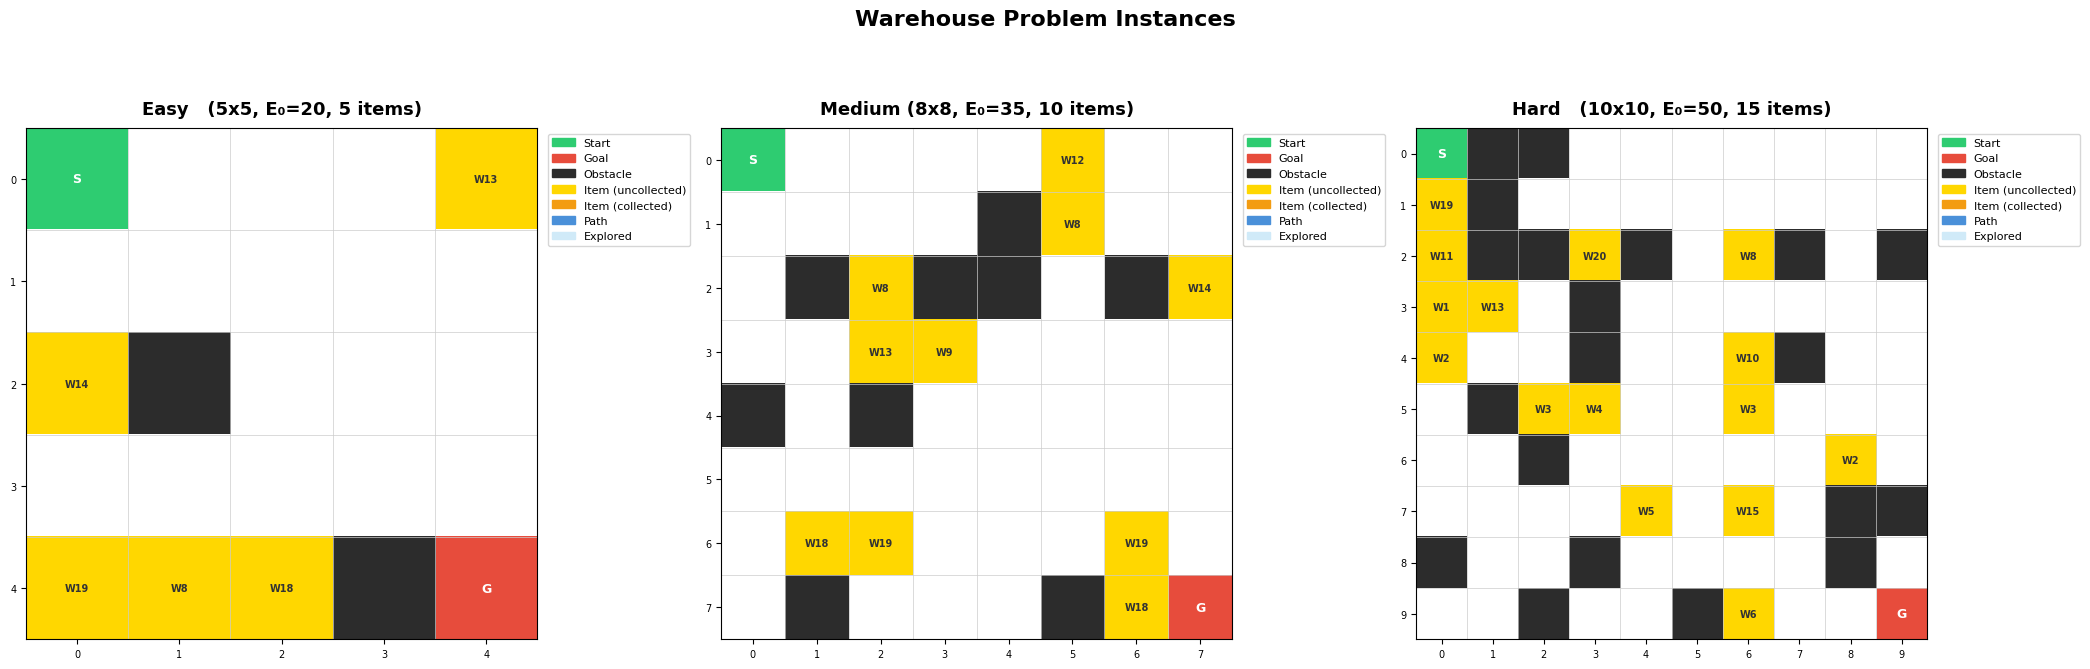

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (env, label) in zip(axes, [
        (env_easy,   'Easy   (5x5, E₀=20, 5 items)'),
        (env_medium, 'Medium (8x8, E₀=35, 10 items)'),
        (env_hard,   'Hard   (10x10, E₀=50, 15 items)'),
]):
    env.render(title=label, ax=ax)

plt.suptitle('Warehouse Problem Instances', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Result Dataclass & Path Reconstruction Utility

In [36]:
class SearchResult:
    """
    Container for the result of a search algorithm run.

    Attributes
    ----------
    found : bool - was a goal state reached?
    path : list of (row,col) - cell sequence from start to goal
    actions : list of str - action sequence
    collected_weight : int - W(π)
    path_length : int - L(π) = number of move actions
    nodes_expanded : int - how many nodes were popped from frontier
    nodes_generated : int - how many nodes were ever added to frontier
    time_sec : float - wall-clock time
    algorithm : str
    heuristic : str or None
    explored_cells : set of (row,col)  - for visualisation
    """
    def __init__(self):
        self.found           = False
        self.path            = []
        self.actions         = []
        self.collected_weight = 0
        self.path_length     = 0
        self.nodes_expanded  = 0
        self.nodes_generated = 0
        self.time_sec        = 0.0
        self.algorithm       = ''
        self.heuristic       = None
        self.explored_cells  = set()

    def __repr__(self):
        status = 'FOUND' if self.found else 'NOT FOUND'
        return (
            f"[{self.algorithm}({self.heuristic})] {status} | "
            f"W={self.collected_weight} | L={self.path_length} | "
            f"Expanded={self.nodes_expanded} | Generated={self.nodes_generated} | "
            f"Time={self.time_sec:.4f}s"
        )


def reconstruct_path(came_from, goal_state):
    """
    Trace back from goal_state through came_from dict.
    came_from maps state → (parent_state, action)
    Returns
    -------
    cells : list of (row,col) from start to goal
    actions : list of action strings
    """
    cells, actions = [], []
    state = goal_state
    while came_from[state] is not None:
        parent, action = came_from[state]
        cells.append((state[0], state[1]))
        actions.append(action)
        state = parent
    cells.append((state[0], state[1]))  # start
    cells.reverse()
    actions.reverse()
    return cells, actions


print("SearchResult and path reconstruction utilities defined.")

SearchResult and path reconstruction utilities defined.


## Algorithm 1 – Breadth-First Search (BFS)

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes (finite state space) |
| **Optimal (max weight)?** | ❌ No – finds shallowest goal, not max-weight |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) |

BFS explores level by level. The first goal state it finds will have the **minimum number of moves** (minimum depth), not necessarily the maximum collected weight.

In [37]:
def bfs(env, max_nodes=500_000):
    """
    Breadth-First Search for the warehouse navigation problem.

    Expands states level-by-level (FIFO queue).
    Returns as soon as the first goal state is reached.

    Parameters
    ----------
    env       : WarehouseEnv
    max_nodes : safety cap on expansions (to avoid running forever on hard instances)

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'BFS'

    start_time = time.perf_counter()

    initial = env.initial_state()

    # FIFO frontier: each entry is a state
    frontier = deque([initial])
    # came_from: state → (parent_state, action) | None for initial
    came_from = {initial: None}

    result.nodes_generated += 1   # initial state

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f"  ⚠️  BFS hit node cap ({max_nodes}). Terminating early.")
            break

        state = frontier.popleft()
        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors
        for action, successor, _ in env.get_successors(state):
            if successor not in came_from:
                came_from[successor] = (state, action)
                frontier.append(successor)
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print("✅ BFS algorithm defined.")

✅ BFS algorithm defined.


In [38]:
print("Running BFS on Easy instance...")
bfs_easy = bfs(env_easy)
print(bfs_easy)

print("\nRunning BFS on Medium instance...")
bfs_medium = bfs(env_medium)
print(bfs_medium)

print("\nRunning BFS on Hard instance (may be slow)...")
bfs_hard = bfs(env_hard, max_nodes=200_000)
print(bfs_hard)

Running BFS on Easy instance...
[BFS(None)] FOUND | W=14 | L=8 | Expanded=166 | Generated=249 | Time=0.0017s

Running BFS on Medium instance...
[BFS(None)] FOUND | W=74 | L=14 | Expanded=1553 | Generated=2271 | Time=0.0198s

Running BFS on Hard instance (may be slow)...
[BFS(None)] FOUND | W=44 | L=18 | Expanded=3586 | Generated=5521 | Time=0.0404s


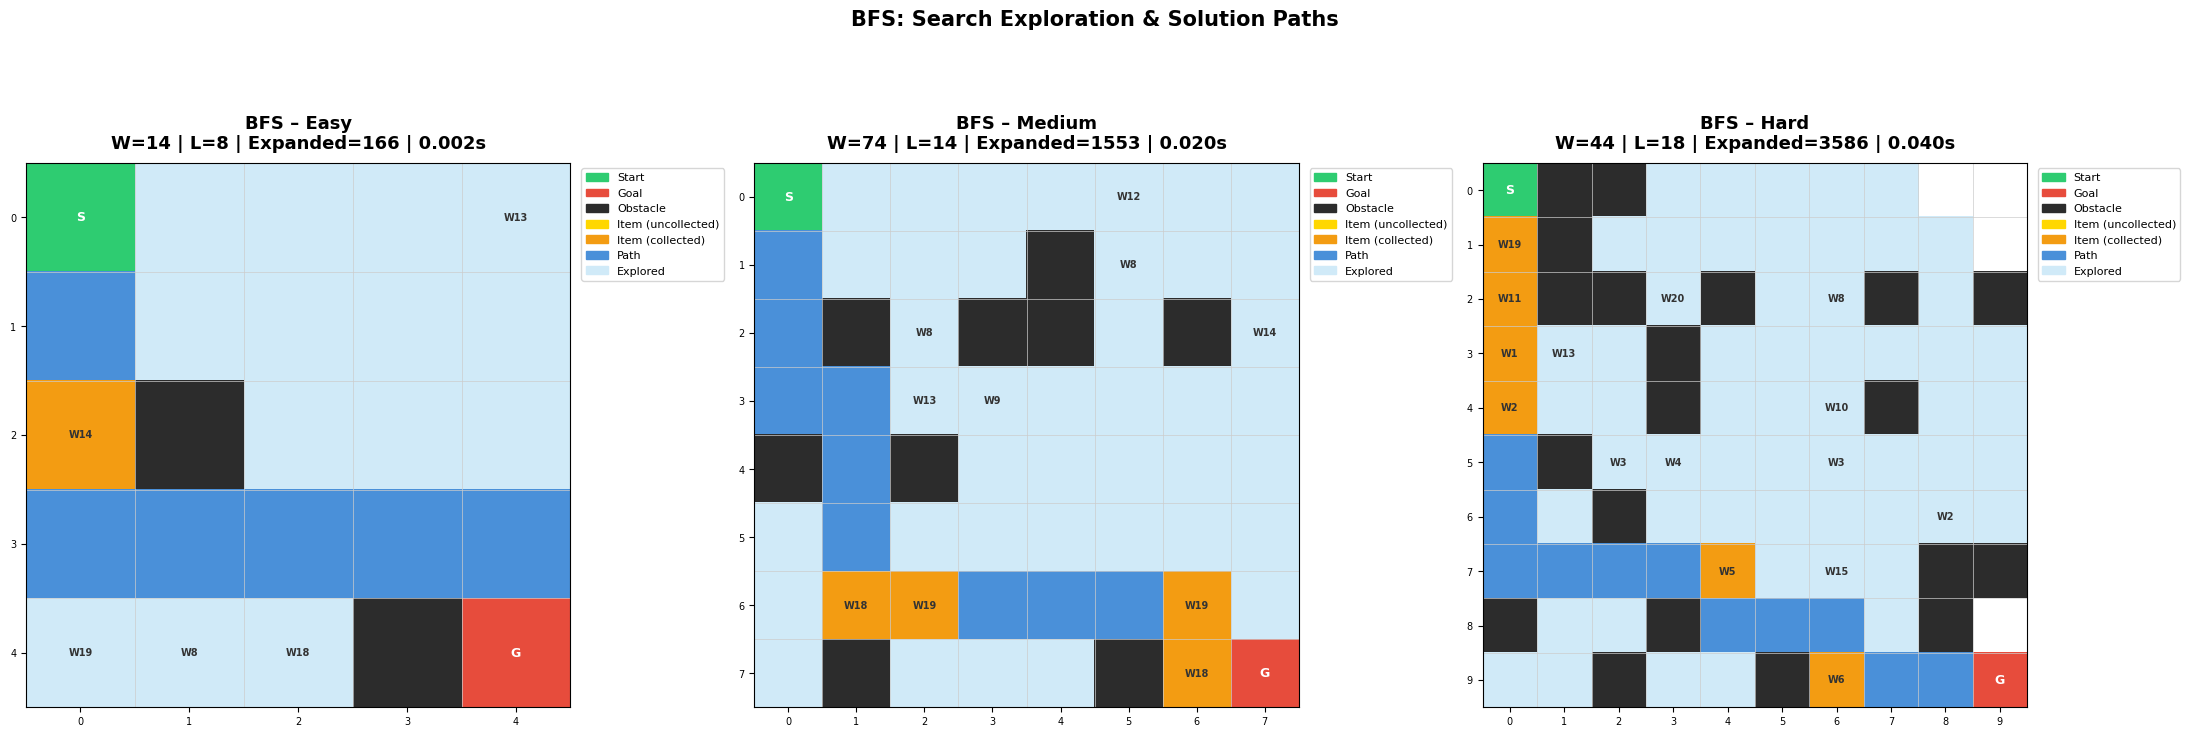

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (env, res, label) in zip(axes, [
    (env_easy,   bfs_easy,   'BFS – Easy'),
    (env_medium, bfs_medium, 'BFS – Medium'),
    (env_hard,   bfs_hard,   'BFS – Hard'),
]):
    info = (f'W={res.collected_weight} | L={res.path_length} | '
            f'Expanded={res.nodes_expanded} | {res.time_sec:.3f}s')
    env.render(
        path=res.path,
        explored=res.explored_cells,
        title=f'{label}\n{info}',
        ax=ax
    )

plt.suptitle('BFS: Search Exploration & Solution Paths', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### BFS – Key Observations

- BFS finds the **shallowest** (fewest moves) path to the goal.
- It explores enormous portions of the grid, explaining the high node count.
- The collected weight is **not guaranteed to be maximum** – BFS stops as soon as any goal is reached, even if a longer path would collect heavier items.
- This confirms the D2 analysis: **BFS is complete but not optimal for max-weight**.


## Algorithm 2 – Uniform Cost Search (UCS)

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes (finite state space, positive step costs) |
| **Optimal (min move cost)?** | ✅ Yes – always expands cheapest path first |
| **Optimal (max weight)?** | ❌ No – minimises moves, not maximises weight |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) |

### How UCS differs from BFS

BFS uses a **FIFO queue** — all edges are treated equally.  
UCS uses a **min-heap (priority queue)** ordered by `g(n)`, the cumulative path cost so far.  

In our problem every Move action costs **1** and every Pickup costs **0**, so `g(n) = L(π)` (number of moves taken).  
That means UCS will select paths by total move cost, which corresponds to the shortest path length in this specific setup.  
The key conceptual difference is that **UCS generalises to non-uniform costs**, while BFS only works correctly for equal-cost transitions.



In [40]:
def ucs(env, max_nodes=500_000):
    """
    Uniform Cost Search for the warehouse navigation problem.

    Frontier is a min-heap ordered by g(n) = cumulative move cost.
    Since every Move costs 1 and Pickup costs 0:
        g(n) = number of move actions taken so far = L(π)

    A state is finalised (never re-expanded) the first time it is
    popped from the priority queue — guaranteed optimal g(n) at that
    point because all step costs are non-negative.

    Parameters
    ----------
    env       : WarehouseEnv
    max_nodes : safety cap on expansions

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'UCS'

    start_time = time.perf_counter()

    initial = env.initial_state()

    # Heap entry: (g_cost, tie_break_counter, state)
    # tie_break_counter ensures stable ordering when g costs are equal
    counter  = 0
    frontier = [(0, counter, initial)]   # (g, counter, state)
    heapq.heapify(frontier)

    # best_g: state → lowest g cost seen so far
    # Allows lazy deletion: if we pop a state with g > best_g[state], skip it
    best_g    = {initial: 0}
    came_from = {initial: None}          # state → (parent, action)

    result.nodes_generated += 1

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f"  ⚠️  UCS hit node cap ({max_nodes}). Terminating early.")
            break

        g, _, state = heapq.heappop(frontier)

        # Lazy deletion: skip stale entries
        if g > best_g.get(state, float('inf')):
            continue

        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check — done here (after pop) to guarantee optimal g
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors
        for action, successor, step_cost in env.get_successors(state):
            new_g = g + step_cost   # step_cost = 1 for Move, 0 for Pickup
            if new_g < best_g.get(successor, float('inf')):
                best_g[successor]    = new_g
                came_from[successor] = (state, action)
                counter += 1
                heapq.heappush(frontier, (new_g, counter, successor))
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print('✅ UCS algorithm defined.')

✅ UCS algorithm defined.


In [41]:
print('Running UCS on Easy instance...')
ucs_easy = ucs(env_easy)
print(ucs_easy)

print('\nRunning UCS on Medium instance...')
ucs_medium = ucs(env_medium)
print(ucs_medium)

print('\nRunning UCS on Hard instance (may be slow)...')
ucs_hard = ucs(env_hard, max_nodes=200_000)
print(ucs_hard)

Running UCS on Easy instance...
[UCS(None)] FOUND | W=14 | L=8 | Expanded=166 | Generated=249 | Time=0.0025s

Running UCS on Medium instance...
[UCS(None)] FOUND | W=74 | L=14 | Expanded=1553 | Generated=2271 | Time=0.0221s

Running UCS on Hard instance (may be slow)...
[UCS(None)] FOUND | W=44 | L=18 | Expanded=3586 | Generated=5521 | Time=0.3501s


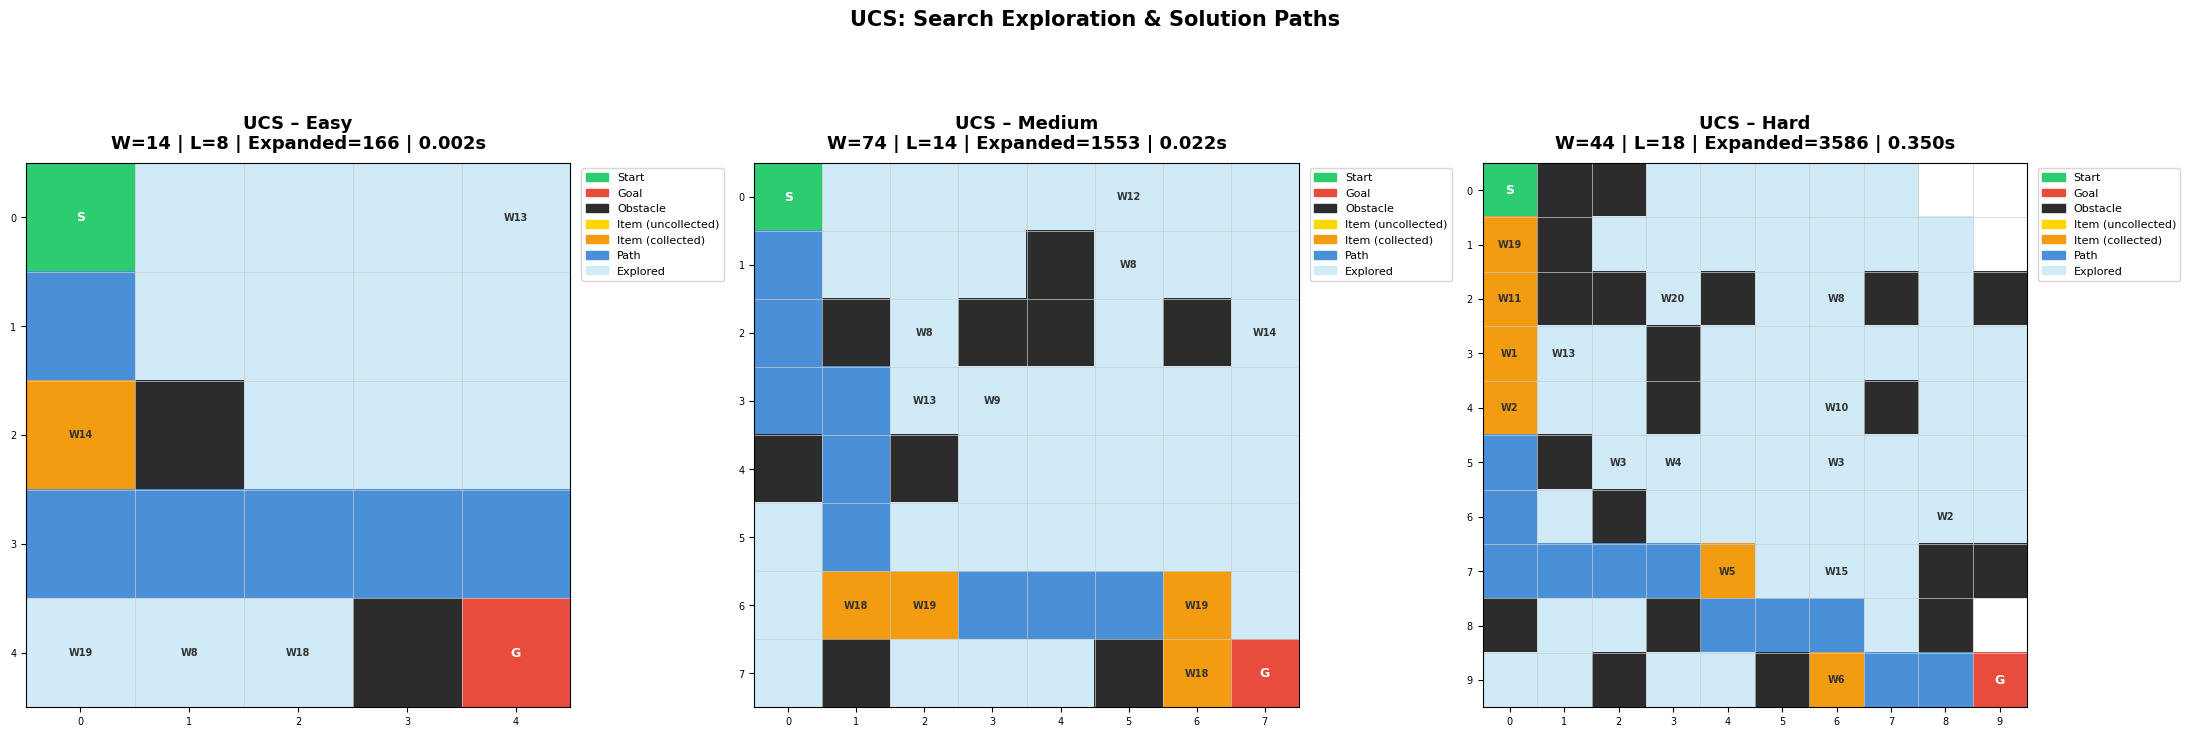

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (env, res, label) in zip(axes, [
    (env_easy,   ucs_easy,   'UCS – Easy'),
    (env_medium, ucs_medium, 'UCS – Medium'),
    (env_hard,   ucs_hard,   'UCS – Hard'),
]):
    info = (f'W={res.collected_weight} | L={res.path_length} | '
            f'Expanded={res.nodes_expanded} | {res.time_sec:.3f}s')
    env.render(
        path=res.path,
        explored=res.explored_cells,
        title=f'{label}\n{info}',
        ax=ax
    )

plt.suptitle('UCS: Search Exploration & Solution Paths', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### UCS – Key Observations

- UCS uses a **min-heap ordered by g(n)** — the cumulative move cost — instead of a FIFO queue.
- Because all Move costs are **uniform (= 1)** in this problem, UCS and BFS expand states in the same order and find the **same minimum-length path**.
- UCS is strictly more general: if move costs were non-uniform (e.g. terrain penalties), UCS would still find the cheapest-cost path while BFS would fail.
- **Neither BFS nor UCS is optimal for the max-weight objective** — both stop at the shallowest/cheapest goal, not the highest-weight one.
- The `best_g` dictionary + lazy deletion is important: without it, UCS could re-expand states and produce incorrect paths.
- This confirms D2: **UCS is complete and optimal w.r.t. move cost, but not w.r.t. max W(π)**.

In [43]:
def manhattan(a, b):
    """Manhattan distance between two (row, col) tuples."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def mst_cost(nodes):
    """
    Prim's algorithm to compute MST cost over a set of grid cells
    using Manhattan distance as edge weight.

    Parameters
    ----------
    nodes : list of (row, col) tuples

    Returns
    -------
    int  total MST edge weight (0 if fewer than 2 nodes)
    """
    if len(nodes) < 2:
        return 0
    nodes = list(nodes)
    in_tree = {nodes[0]}
    # min-heap: (edge_cost, node)
    heap = [(manhattan(nodes[0], v), v) for v in nodes[1:]]
    heapq.heapify(heap)
    total = 0
    while len(in_tree) < len(nodes):
        cost, u = heapq.heappop(heap)
        if u in in_tree:
            continue
        in_tree.add(u)
        total += cost
        for v in nodes:
            if v not in in_tree:
                heapq.heappush(heap, (manhattan(u, v), v))
    return total


def h1(state, env):
    """
    Heuristic 1: Manhattan distance to nearest remaining item.
    If no items remain, Manhattan distance to goal.

    Admissible: ignores obstacles → never overestimates true cost.
    Consistent: satisfies triangle inequality.
    """
    x, y, remaining, _ = state
    robot = (x, y)
    if not remaining:
        return manhattan(robot, env.goal)
    return min(manhattan(robot, env.item_positions[i]) for i in remaining)


def h2(state, env):
    """
    Heuristic 2: MST-based heuristic.
      h2 = dist(robot → nearest item)
         + MST(remaining item positions)
         + min dist(any item → goal)

    If no items remain, falls back to dist(robot → goal).

    Admissible & consistent (proven in D1).
    Dominates h1.
    """
    x, y, remaining, _ = state
    robot = (x, y)
    if not remaining:
        return manhattan(robot, env.goal)

    item_coords = [env.item_positions[i] for i in remaining]
    dist_to_nearest = min(manhattan(robot, p) for p in item_coords)
    mst            = mst_cost(item_coords)
    dist_to_goal   = min(manhattan(p, env.goal) for p in item_coords)
    return dist_to_nearest + mst + dist_to_goal


print("✅ Heuristics h1 and h2 defined.")

# Quick sanity check on easy instance
s0 = env_easy.initial_state()
print(f"   h1(s0) = {h1(s0, env_easy)}")
print(f"   h2(s0) = {h2(s0, env_easy)}  (should be ≥ h1)")

✅ Heuristics h1 and h2 defined.
   h1(s0) = 2
   h2(s0) = 14  (should be ≥ h1)


---
## Algorithm 3 – Greedy Best-First Search

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes – with explored set, finite state space |
| **Optimal (max weight)?** | ❌ No – greedy choices can miss high-weight detours |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) worst case |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) worst case |

### How Greedy differs from BFS and UCS

| Algorithm | Frontier ordering | Uses g(n)? | Uses h(n)? |
|---|---|---|---|
| BFS | FIFO | ❌ | ❌ |
| UCS | min g(n) | ✅ | ❌ |
| **Greedy** | **min h(n)** | **❌** | **✅** |
| A* | min g(n)+h(n) | ✅ | ✅ |

Greedy **ignores how far it has already travelled** (`g(n)`) and purely chases what looks closest to the goal according to the heuristic.  
This makes it fast in practice — but it can be led astray by the heuristic and miss better solutions that require a temporary detour.

### Why Greedy is not optimal for max-weight
Greedy expands the node that *looks* closest to items/delivery, but never accounts for:
- How much weight has been collected so far
- Whether a slightly farther item is worth much more
- The energy cost of the detour

D2 counterexample: if π₁ reaches goal in 4 moves with W=5 and π₂ reaches in 6 moves with W=50,  
Greedy follows π₁ because heuristic distance decreases faster — **but W(π₂) >> W(π₁)**.

### Two variants
We run Greedy with **both h1 and h2** so we can compare their guidance quality.

In [44]:
def greedy(env, heuristic, heuristic_name='h?', max_nodes=500_000):
    """
    Greedy Best-First Search for the warehouse navigation problem.

    Frontier is a min-heap ordered by h(n) ONLY.
    g(n) is NOT used in the priority — this is the defining feature
    that separates Greedy from A*.

    An explored (closed) set is maintained to guarantee completeness
    in the finite state space (without it, Greedy may loop).

    Parameters
    ----------
    env            : WarehouseEnv
    heuristic      : callable  h(state, env) → float
    heuristic_name : str       label for reporting
    max_nodes      : safety cap on expansions

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'Greedy'
    result.heuristic = heuristic_name

    start_time = time.perf_counter()

    initial = env.initial_state()

    # Heap entry: (h_value, tie_break_counter, state)
    # tie_break_counter ensures stable ordering when h values are equal
    counter  = 0
    h_init   = heuristic(initial, env)
    frontier = [(h_init, counter, initial)]
    heapq.heapify(frontier)

    came_from = {initial: None}   # state → (parent, action)
    explored  = set()             # states already expanded

    result.nodes_generated += 1

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f'  ⚠️  Greedy({heuristic_name}) hit node cap ({max_nodes}).'
                  ' Terminating early.')
            break

        h_val, _, state = heapq.heappop(frontier)

        # Skip if already expanded (lazy duplicate handling)
        if state in explored:
            continue
        explored.add(state)

        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors — order by h(successor) only, NOT g
        for action, successor, _ in env.get_successors(state):
            if successor not in explored:
                if successor not in came_from:
                    came_from[successor] = (state, action)
                h_succ = heuristic(successor, env)
                counter += 1
                heapq.heappush(frontier, (h_succ, counter, successor))
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print('✅ Greedy Best-First Search defined.')

✅ Greedy Best-First Search defined.


### Run Greedy (h1 and h2) on All Three Instances

In [45]:
print('=== EASY ===')
greedy_h1_easy = greedy(env_easy, h1, 'h1')
print(greedy_h1_easy)
greedy_h2_easy = greedy(env_easy, h2, 'h2')
print(greedy_h2_easy)

print('\n=== MEDIUM ===')
greedy_h1_medium = greedy(env_medium, h1, 'h1')
print(greedy_h1_medium)
greedy_h2_medium = greedy(env_medium, h2, 'h2')
print(greedy_h2_medium)

print('\n=== HARD ===')
greedy_h1_hard = greedy(env_hard, h1, 'h1', max_nodes=200_000)
print(greedy_h1_hard)
greedy_h2_hard = greedy(env_hard, h2, 'h2', max_nodes=200_000)
print(greedy_h2_hard)

=== EASY ===
[Greedy(h1)] FOUND | W=14 | L=8 | Expanded=204 | Generated=362 | Time=0.0029s
[Greedy(h2)] FOUND | W=59 | L=10 | Expanded=24 | Generated=47 | Time=0.0006s

=== MEDIUM ===
[Greedy(h1)] FOUND | W=19 | L=14 | Expanded=777 | Generated=1799 | Time=0.0195s
[Greedy(h2)] FOUND | W=86 | L=18 | Expanded=29 | Generated=90 | Time=0.0030s

=== HARD ===
[Greedy(h1)] FOUND | W=43 | L=18 | Expanded=26582 | Generated=60052 | Time=0.7759s
[Greedy(h2)] FOUND | W=60 | L=24 | Expanded=824 | Generated=1717 | Time=0.0426s


### Visualise Greedy (h1 vs h2) on Each Instance

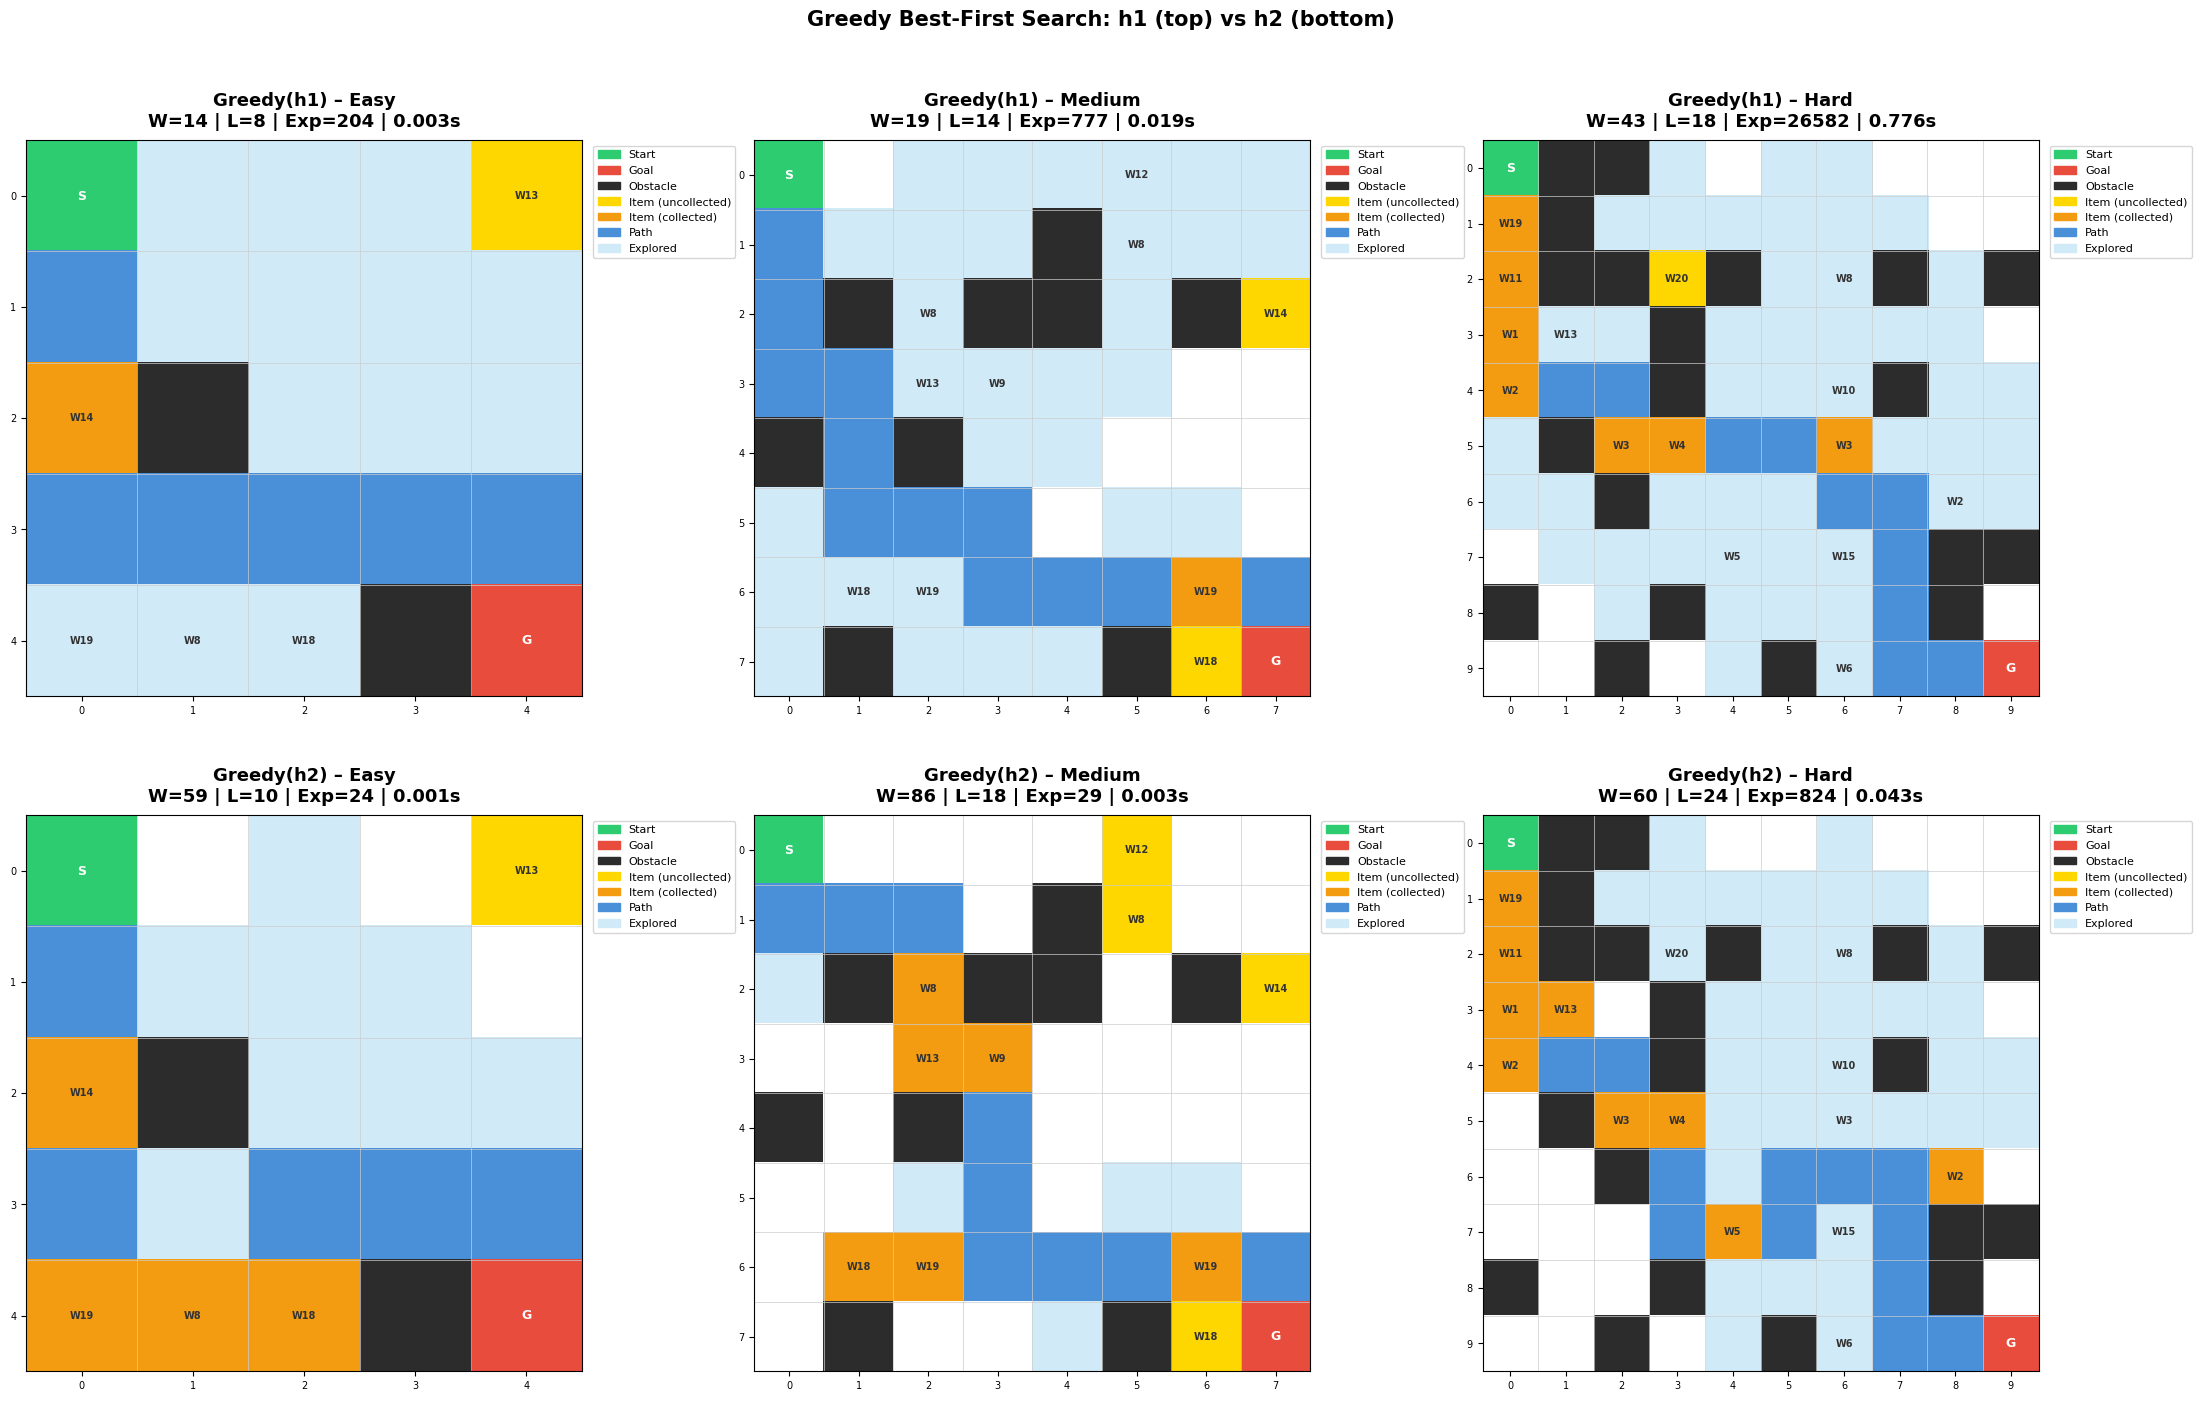

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

rows = [
    (greedy_h1_easy, greedy_h1_medium, greedy_h1_hard, 'Greedy – h1 (Manhattan to nearest item)'),
    (greedy_h2_easy, greedy_h2_medium, greedy_h2_hard, 'Greedy – h2 (MST-based)'),
]

envs   = [env_easy, env_medium, env_hard]
labels = ['Easy', 'Medium', 'Hard']

for row_idx, (r_easy, r_medium, r_hard, row_title) in enumerate(rows):
    for col_idx, (env, res, diff) in enumerate(
            zip(envs, [r_easy, r_medium, r_hard], labels)):
        ax   = axes[row_idx][col_idx]
        info = (f'W={res.collected_weight} | L={res.path_length} | '
                f'Exp={res.nodes_expanded} | {res.time_sec:.3f}s')
        env.render(
            path=res.path,
            explored=res.explored_cells,
            title=f'Greedy({res.heuristic}) – {diff}\n{info}',
            ax=ax
        )

plt.suptitle('Greedy Best-First Search: h1 (top) vs h2 (bottom)', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Greedy – Key Observations

- Greedy orders the frontier by **h(n) only** — it ignores `g(n)` entirely. This is the key implementation difference from A*.
- The **explored set is mandatory** for completeness. Without it, Greedy can oscillate between two states indefinitely (e.g. moving toward an item then away as heuristic flips).
- **h2 dominates h1** (proven in D1): h2 is always ≥ h1. In practice, h2 provides richer guidance and typically expands fewer nodes on structured problems.
- Greedy is **fast** — it rushes toward items and the goal — but it can be **myopic**: a high-weight item slightly off the greedy path may be completely ignored.
- **Neither h1 nor h2 Greedy guarantees maximum W(π)** — this confirms D2's non-optimality analysis.
- The bar charts show the trade-off clearly: Greedy expands far fewer nodes than BFS/UCS, but the collected weight is not guaranteed to be optimal.

---
## Algorithm 4 – A* Search

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes (finite state space, positive step costs) |
| **Optimal (min move cost)?** | ✅ Yes – with admissible & consistent heuristic |
| **Optimal (max weight)?** | ❌ No – minimises `f(n) = g(n) + h(n)`, not maximises W(π) |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) worst case |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) worst case |

### How A* differs from BFS, UCS, and Greedy

| Algorithm | Priority key | Uses g(n)? | Uses h(n)? |
|---|---|---|---|
| BFS | insertion order (FIFO) | ❌ | ❌ |
| UCS | `g(n)` | ✅ | ❌ |
| Greedy | `h(n)` | ❌ | ✅ |
| **A\*** | **`f(n) = g(n) + h(n)`** | ✅ | ✅ |

A* combines the **cost-so-far** from UCS with the **heuristic guidance** from Greedy.  
This makes it far more efficient than UCS in practice while preserving optimality guarantees.

### Why A* is still not optimal for max-weight

A* is optimal w.r.t. the function it **minimises** — here `g(n) = L(π)` (move count).  
Our objective is to **maximise** `W(π)`.  
A* will return the path with the fewest moves, which may completely skip heavy items reachable within the energy budget.  
This is exactly why Modified A* (Algorithm 5) is needed.

In [47]:
def astar(env, heuristic_fn, heuristic_name='h', max_nodes=500_000):
    """
    A* Search for the warehouse navigation problem.

    Frontier is a min-heap ordered by f(n) = g(n) + h(n), where:
      g(n) = number of move actions taken so far  (path cost)
      h(n) = heuristic estimate of remaining cost (h1 or h2)

    With an admissible and consistent heuristic, A* is:
      - Complete  : yes (finite state space)
      - Optimal   : yes w.r.t. minimising g(n) = L(π)
      - NOT optimal w.r.t. maximising W(π)

    Parameters
    ----------
    env            : WarehouseEnv
    heuristic_fn   : callable(state, env) → float   (h1 or h2)
    heuristic_name : str label for reporting
    max_nodes      : safety cap on expansions

    Returns
    -------
    SearchResult
    """
    result = SearchResult()
    result.algorithm = 'A*'
    result.heuristic = heuristic_name

    start_time = time.perf_counter()

    initial = env.initial_state()
    h0      = heuristic_fn(initial, env)

    # Heap entry: (f, tie_break_counter, g, state)
    # Tie-break on counter (insertion order) to avoid comparing states
    counter  = 0
    frontier = [(h0, counter, 0, initial)]   # f = g + h; g = 0 at start
    heapq.heapify(frontier)

    # best_g[state] = lowest g value at which state was reached
    # Used for lazy-deletion: stale (higher-g) entries are skipped on pop
    best_g    = {initial: 0}
    came_from = {initial: None}    # state → (parent_state, action)

    result.nodes_generated += 1

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f'  ⚠️  A*({heuristic_name}) hit node cap ({max_nodes}). Terminating early.')
            break

        f, _, g, state = heapq.heappop(frontier)

        # Lazy deletion: skip if we've already found a cheaper path to this state
        if g > best_g.get(state, float('inf')):
            continue

        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # Goal check — after pop, guarantees optimal g for this state
        if env.is_goal(state):
            result.found = True
            result.path, result.actions = reconstruct_path(came_from, state)
            result.collected_weight = env.collected_weight(state)
            result.path_length = sum(1 for a in result.actions
                                     if a.startswith('Move'))
            break

        # Expand successors
        for action, successor, step_cost in env.get_successors(state):
            new_g = g + step_cost
            if new_g < best_g.get(successor, float('inf')):
                best_g[successor]    = new_g
                came_from[successor] = (state, action)
                h_val  = heuristic_fn(successor, env)
                new_f  = new_g + h_val
                counter += 1
                heapq.heappush(frontier, (new_f, counter, new_g, successor))
                result.nodes_generated += 1

    result.time_sec = time.perf_counter() - start_time
    return result


print('✅ A* algorithm defined.')

✅ A* algorithm defined.


### Run A* (h1 and h2) on All Three Instances

In [48]:
print('=== EASY ===')
astar_h1_easy = astar(env_easy, h1, 'h1')
print(astar_h1_easy)
astar_h2_easy = astar(env_easy, h2, 'h2')
print(astar_h2_easy)

print('\n=== MEDIUM ===')
astar_h1_medium = astar(env_medium, h1, 'h1')
print(astar_h1_medium)
astar_h2_medium = astar(env_medium, h2, 'h2')
print(astar_h2_medium)

print('\n=== HARD ===')
astar_h1_hard = astar(env_hard, h1, 'h1', max_nodes=200_000)
print(astar_h1_hard)
astar_h2_hard = astar(env_hard, h2, 'h2', max_nodes=200_000)
print(astar_h2_hard)

=== EASY ===
[A*(h1)] FOUND | W=14 | L=8 | Expanded=154 | Generated=254 | Time=0.0026s
[A*(h2)] FOUND | W=13 | L=8 | Expanded=46 | Generated=88 | Time=0.0017s

=== MEDIUM ===
[A*(h1)] FOUND | W=20 | L=14 | Expanded=1048 | Generated=1711 | Time=0.0210s
[A*(h2)] FOUND | W=34 | L=14 | Expanded=65 | Generated=142 | Time=0.0064s

=== HARD ===
[A*(h1)] FOUND | W=43 | L=18 | Expanded=4218 | Generated=7123 | Time=0.0990s
[A*(h2)] FOUND | W=79 | L=20 | Expanded=844 | Generated=1547 | Time=0.0703s


### Visualise A* Solution Paths (h1 vs h2)

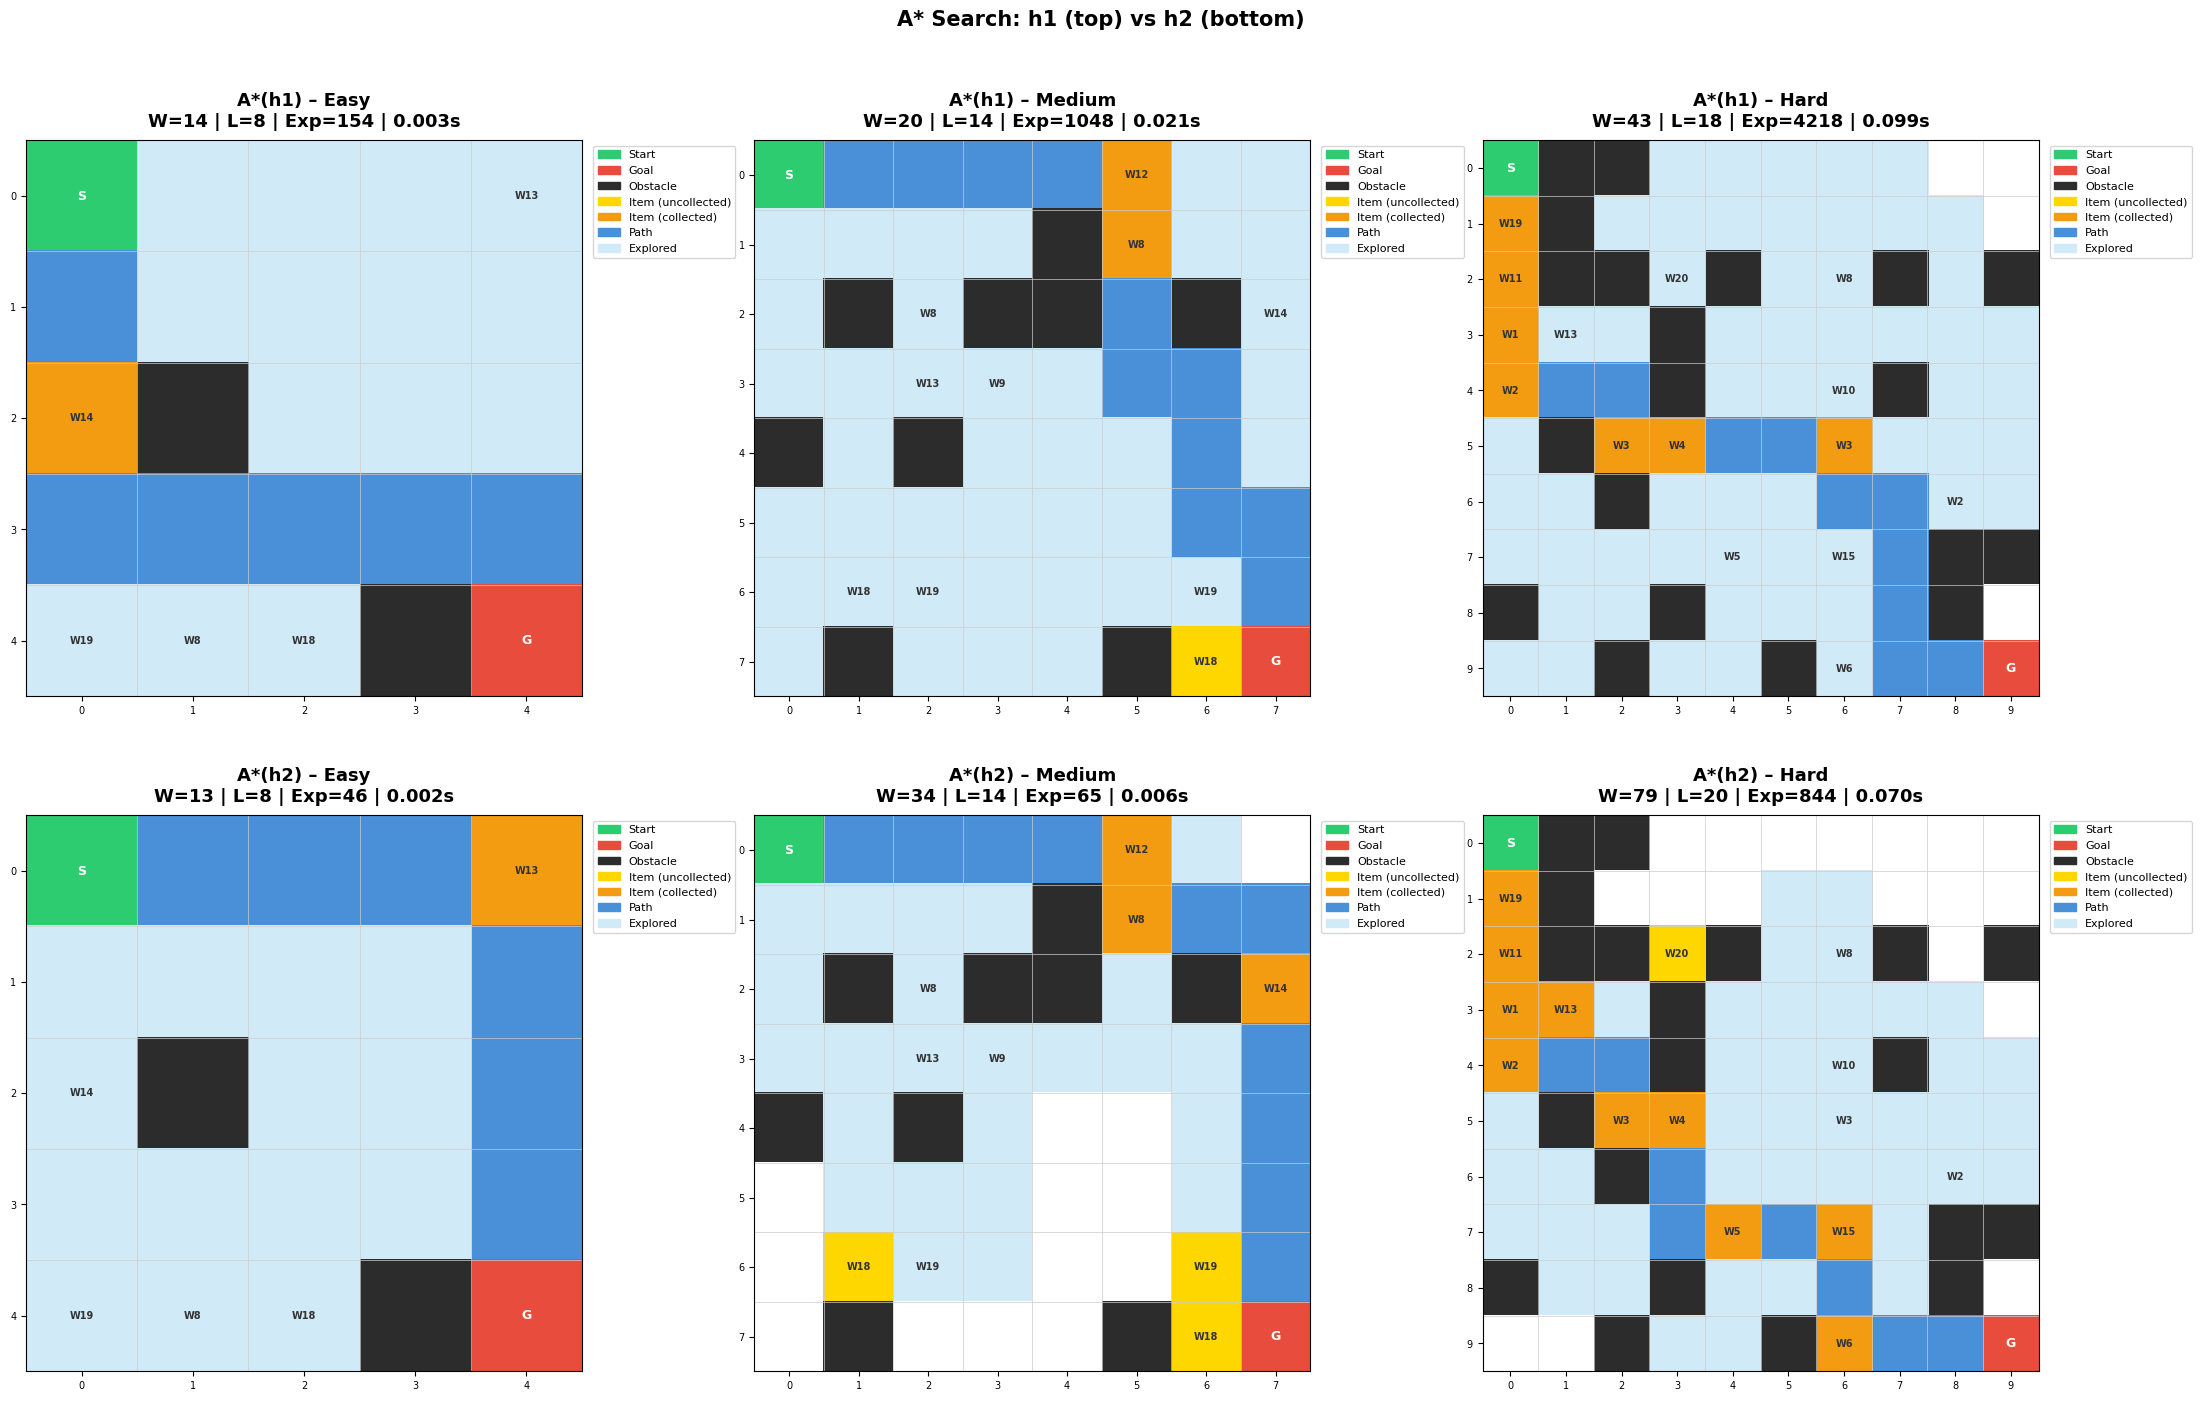

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

rows = [
    (astar_h1_easy, astar_h1_medium, astar_h1_hard, 'A* – h1 (Manhattan to nearest item)'),
    (astar_h2_easy, astar_h2_medium, astar_h2_hard, 'A* – h2 (MST-based)'),
]

envs   = [env_easy, env_medium, env_hard]
labels = ['Easy', 'Medium', 'Hard']

for row_idx, (r_easy, r_medium, r_hard, row_title) in enumerate(rows):
    for col_idx, (env, res, diff) in enumerate(
            zip(envs, [r_easy, r_medium, r_hard], labels)):
        ax   = axes[row_idx][col_idx]
        info = (f'W={res.collected_weight} | L={res.path_length} | '
                f'Exp={res.nodes_expanded} | {res.time_sec:.3f}s')
        env.render(
            path=res.path,
            explored=res.explored_cells,
            title=f'A*({res.heuristic}) – {diff}\n{info}',
            ax=ax
        )

plt.suptitle('A* Search: h1 (top) vs h2 (bottom)', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### A* – Key Observations

- A* uses `f(n) = g(n) + h(n)` — it balances **cost paid so far** with **estimated cost remaining**. This is the crucial difference from Greedy (which ignores `g`) and UCS (which ignores `h`).
- With an **admissible and consistent** heuristic, A* is guaranteed to find the path with **minimum move cost** `L(π)`. It will never re-expand a state once popped (thanks to the `best_g` lazy-deletion guard).
- **h2 dominates h1**: because `h2(s) ≥ h1(s)` for all states, A*(h2) has a tighter lower bound and prunes more of the search tree — confirmed by the node expansion table above.
- **A* is not optimal for max W(π)**: it finds the shortest path to the goal, not the highest-weight path. A path using fewer moves but collecting zero items will be preferred over a slightly longer path collecting heavy items.
- This motivates **Algorithm 5 (Modified A*)**, which flips the objective from minimising move cost to maximising collected weight using a Branch-and-Bound strategy.

---
## Algorithm 5 – Modified A* (Branch-and-Bound for Maximum Weight)

### Theoretical Properties (from D2)
| Property | Value |
|---|---|
| **Complete?** | ✅ Yes – explores all non-pruned feasible states |
| **Optimal (max weight)?** | ✅ Yes – the **only** algorithm here that is |
| **Time Complexity** | O(b^d) = O(5^(E₀+k)) worst case (pruning helps in practice) |
| **Space Complexity** | O(b^d) = O(5^(E₀+k)) worst case |

### Core Idea

Standard A* **minimises** `f(n) = g(n) + h(n)`.  
Modified A* **maximises** `F(s) = G(s) + U(s)` where:

| Symbol | Meaning |
|---|---|
| `G(s)` | Weight **already collected** along the path to state `s` |
| `U(s)` | **Upper bound** on additional weight collectible from `s` within remaining energy |
| `F(s)` | Upper bound on the **best total weight** achievable through `s` |

The frontier is a **max-heap** (largest `F(s)` first) — the opposite of standard A*.

### Upper Bound U(s) — how it's computed

For state `s = (x, y, R, e)`, item `i ∈ R` is **individually feasible** if:
```
d(robot, i) + d(i, goal) ≤ e      (Manhattan, ignoring obstacles)
```
Define `R' = { i ∈ R | individually feasible }`.  
Then `U(s) = Σ w(i) for all i ∈ R'`.

This is a **valid upper bound** because it relaxes the problem (ignores obstacles, ignores item-to-item travel cost). It may overestimate — which is safe for pruning.

### Branch-and-Bound Pruning Rule

Maintain `best` = highest `W(π)` found at any goal state so far.  
For each generated node `s`: if `F(s) ≤ best`, **prune** it — even in the best case, `s` cannot beat the current best solution.

### Why this is optimal (proof sketch from D2)

- `U(s) ≥ OPT(s)` (relaxed upper bound never underestimates)
- Therefore `F(s) = G(s) + U(s) ≥ G(s) + OPT(s)` = true best achievable through `s`
- If `F(s) ≤ best`, no completion of `s` can exceed `best` → safe to prune
- When the frontier is exhausted (no `F(s) > best`), the current `best` is globally optimal ✅

In [50]:
def upper_bound(state, env):
    """
    Compute U(s): upper bound on additional weight collectible from state s.

    An item i ∈ R is individually feasible if the robot can detour to it
    and still reach the goal within remaining energy:
        d(robot, i) + d(i, goal) <= e
    (Manhattan distance — obstacles ignored, relaxed problem)

    U(s) = Σ w(i) for all individually feasible i ∈ R.

    Valid upper bound: may overestimate (ignores inter-item travel costs
    and obstacles) but never underestimates. Safe for B&B pruning.

    Tighter than 'sum of all remaining weights' because items that are
    provably unreachable given the remaining energy are excluded.
    """
    x, y, remaining, e = state
    robot = (x, y)
    total = 0
    for i in remaining:
        item_pos = env.item_positions[i]
        if manhattan(robot, item_pos) + manhattan(item_pos, env.goal) <= e:
            total += env.item_weights[i]
    return total


def modified_astar(env, max_nodes=2_000_000):
    """
    Modified A* — Branch-and-Bound for Maximum Weight Collection.

    Objective : MAXIMISE F(s) = G(s) + U(s)
      G(s) = weight collected so far along path to s
      U(s) = upper bound on additional collectible weight from s

    Key differences from standard A*
    ---------------------------------
    1. Max-heap (largest F first) via negation in Python's min-heapq.
    2. Does NOT stop at first goal — records best and keeps searching.
    3. B&B pruning: discard node s if F(s) <= best_weight_so_far.
    4. Lazy-deletion via (G_at_push, state) stored in heap:
         On pop, if the recorded G no longer matches best_G[state],
         the entry is stale (a better path to this state was found
         later and already expanded) — skip it.
         Crucially, best_G is updated only at EXPANSION time (pop),
         not at generation time (push). This prevents a worse path
         that is generated first from blocking a better path that
         arrives later.
    5. came_from is snapshotted only when a new best goal is found,
         so path reconstruction is always consistent.

    Why max_nodes is higher than other algorithms
    ----------------------------------------------
    Modified A* cannot stop early — it must prove no remaining branch
    can beat the best solution, which requires more expansions than
    algorithms that stop at the first goal. The B&B pruning compensates
    significantly in practice, but the cap must be generous enough to
    not cut off before the proof is complete.

    Parameters
    ----------
    env       : WarehouseEnv
    max_nodes : safety cap on expansions (default raised to 2M)

    Returns
    -------
    SearchResult with optimal W(π)
    """
    result = SearchResult()
    result.algorithm = 'ModifiedA*'
    result.heuristic = 'U(s)'

    start_time = time.perf_counter()

    initial = env.initial_state()
    G_init  = 0
    U_init  = upper_bound(initial, env)
    F_init  = G_init + U_init

    # Heap entry: (-F, counter, -G, state)
    # -F  → max-heap via min-heapq
    # -G  → carried so we know what G was when this entry was pushed
    #         (used for lazy-deletion on pop)
    counter  = 0
    frontier = [(-F_init, counter, -G_init, initial)]
    heapq.heapify(frontier)

    # best_G[state] = highest G at which state was EXPANDED (not just generated).
    # Updated only on pop — prevents a stale early-generated entry from
    # blocking a better later-generated entry for the same state.
    best_G    = {}                  # populated lazily at expansion time
    came_from = {initial: None}     # live path-tracking dict

    best_weight     = -1            # best W(π) at any complete goal path
    best_goal_state = None
    best_came_from  = None          # snapshot of came_from at best goal

    result.nodes_generated += 1

    while frontier:
        if result.nodes_expanded >= max_nodes:
            print(f'  ⚠️  ModifiedA* hit node cap ({max_nodes:,}). '
                  f'Best weight so far: {best_weight} '
                  f'(result may be sub-optimal)')
            break

        neg_F, _, neg_G, state = heapq.heappop(frontier)
        F = -neg_F
        G = -neg_G

        # ── B&B pruning (cheap check first) ──────────────────────────────
        # Even in the best case this node cannot beat current best → skip
        if F <= best_weight:
            continue

        # ── Lazy-deletion ─────────────────────────────────────────────────
        # If we've already expanded this state with a higher-or-equal G,
        # this entry is stale — a better path already explored this state.
        if G < best_G.get(state, -1):
            continue

        # ── Mark as expanded at this G ────────────────────────────────────
        best_G[state] = G
        result.nodes_expanded += 1
        result.explored_cells.add((state[0], state[1]))

        # ── Goal check ───────────────────────────────────────────────────
        # Record if best; do NOT return — keep searching for a better goal.
        if env.is_goal(state):
            if G > best_weight:
                best_weight     = G
                best_goal_state = state
                best_came_from  = dict(came_from)   # snapshot for reconstruction
            continue

        # ── Expand successors ─────────────────────────────────────────────
        for action, successor, _ in env.get_successors(state):
            # Weight gained on this step = difference in collected weight
            # (auto-pickup is encoded in the state transition)
            step_weight = (env.collected_weight(successor)
                           - env.collected_weight(state))
            succ_G = G + step_weight

            # Skip if we've already expanded this successor with a higher G
            if succ_G < best_G.get(successor, -1):
                continue

            succ_U = upper_bound(successor, env)
            succ_F = succ_G + succ_U

            # B&B pruning at generation time
            if succ_F <= best_weight:
                continue

            # Update came_from (safe — we only snapshot it at goal time)
            came_from[successor] = (state, action)
            counter += 1
            heapq.heappush(frontier, (-succ_F, counter, -succ_G, successor))
            result.nodes_generated += 1

    # ── Reconstruct optimal path ──────────────────────────────────────────
    if best_goal_state is not None:
        result.found = True
        result.path, result.actions = reconstruct_path(
            best_came_from, best_goal_state)
        result.collected_weight = best_weight
        result.path_length = sum(
            1 for a in result.actions if a.startswith('Move'))

    result.time_sec = time.perf_counter() - start_time
    return result


print('✅ Modified A* (Branch-and-Bound) defined — lazy-deletion fixed.')

✅ Modified A* (Branch-and-Bound) defined — lazy-deletion fixed.


### Run Modified A* on All Three Instances

In [51]:
print('Running Modified A* on Easy instance...')
mAstar_easy = modified_astar(env_easy)
print(mAstar_easy)

print('\nRunning Modified A* on Medium instance...')
mAstar_medium = modified_astar(env_medium)
print(mAstar_medium)

print('\nRunning Modified A* on Hard instance...')
mAstar_hard = modified_astar(env_hard)
print(mAstar_hard)

Running Modified A* on Easy instance...
[ModifiedA*(U(s))] FOUND | W=59 | L=10 | Expanded=240 | Generated=359 | Time=0.0035s

Running Modified A* on Medium instance...
[ModifiedA*(U(s))] FOUND | W=104 | L=18 | Expanded=10805 | Generated=35769 | Time=0.6120s

Running Modified A* on Hard instance...
[ModifiedA*(U(s))] FOUND | W=100 | L=30 | Expanded=369687 | Generated=1199101 | Time=30.4240s


### Visualise Modified A* Solution Paths

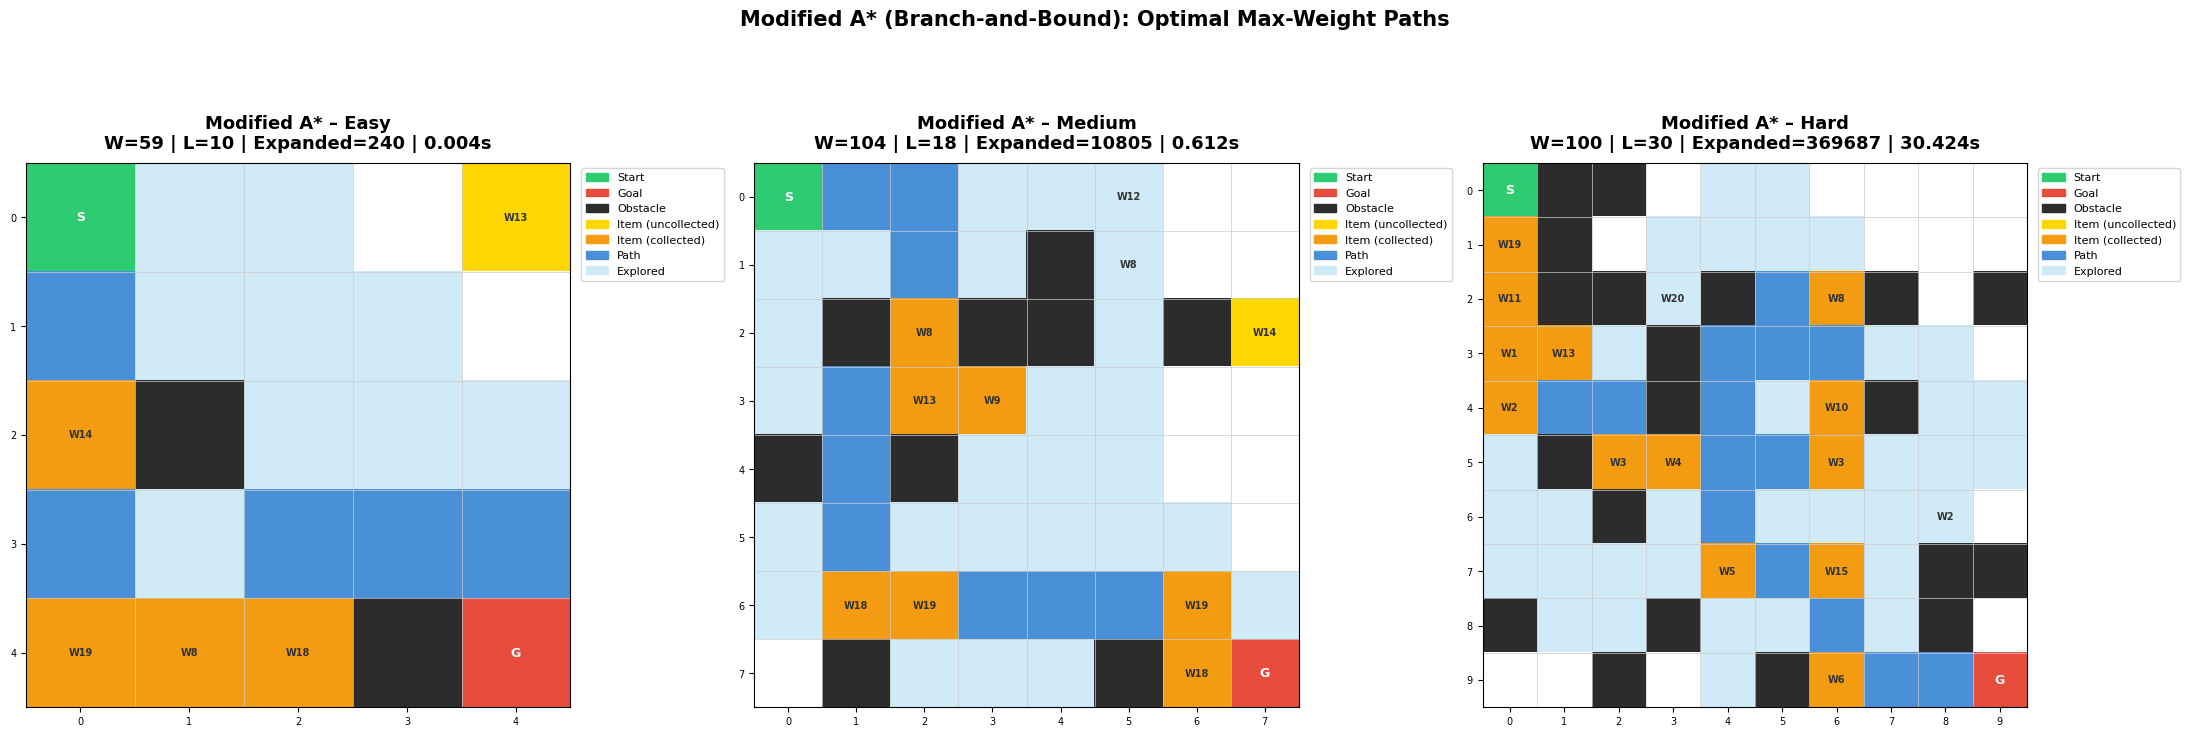

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (env, res, label) in zip(axes, [
    (env_easy,   mAstar_easy,   'Modified A* – Easy'),
    (env_medium, mAstar_medium, 'Modified A* – Medium'),
    (env_hard,   mAstar_hard,   'Modified A* – Hard'),
]):
    info = (f'W={res.collected_weight} | L={res.path_length} | '
            f'Expanded={res.nodes_expanded} | {res.time_sec:.3f}s')
    env.render(
        path=res.path,
        explored=res.explored_cells,
        title=f'{label}\n{info}',
        ax=ax
    )

plt.suptitle('Modified A* (Branch-and-Bound): Optimal Max-Weight Paths',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Final Empirical Comparison – All 7 Algorithm Runs

This is the D2 validation section: do our actual results match the theoretical complexity predictions?

In [53]:
def compare_table(results, labels):
    """
    Print a formatted comparison table for a list of SearchResult objects.
    """
    header = f"{'Algorithm':<20} {'Found':>6} {'W(π)':>6} {'L(π)':>6} " \
             f"{'Expanded':>10} {'Generated':>11} {'Time(s)':>9}"
    sep    = '-' * len(header)
    print(sep)
    print(header)
    print(sep)
    for res, lbl in zip(results, labels):
        print(f"{lbl:<20} {str(res.found):>6} {res.collected_weight:>6} "
              f"{res.path_length:>6} {res.nodes_expanded:>10} "
              f"{res.nodes_generated:>11} {res.time_sec:>9.4f}")
    print(sep)


print("compare_table() defined.")

# ── Full summary table ──────────────────────────────────────────────────────
for difficulty, envx, results_dict in [
    ('EASY', env_easy, {
        'BFS':          bfs_easy,
        'UCS':          ucs_easy,
        'Greedy(h1)':   greedy_h1_easy,
        'Greedy(h2)':   greedy_h2_easy,
        'A*(h1)':       astar_h1_easy,
        'A*(h2)':       astar_h2_easy,
        'ModifiedA*':   mAstar_easy,
    }),
    ('MEDIUM', env_medium, {
        'BFS':          bfs_medium,
        'UCS':          ucs_medium,
        'Greedy(h1)':   greedy_h1_medium,
        'Greedy(h2)':   greedy_h2_medium,
        'A*(h1)':       astar_h1_medium,
        'A*(h2)':       astar_h2_medium,
        'ModifiedA*':   mAstar_medium,
    }),
    ('HARD', env_hard, {
        'BFS':          bfs_hard,
        'UCS':          ucs_hard,
        'Greedy(h1)':   greedy_h1_hard,
        'Greedy(h2)':   greedy_h2_hard,
        'A*(h1)':       astar_h1_hard,
        'A*(h2)':       astar_h2_hard,
        'ModifiedA*':   mAstar_hard,
    }),
]:
    print(f'\n=== {difficulty} (N={envx.N}, E₀={envx.E0}, k={envx.k}) ===')
    compare_table(list(results_dict.values()), list(results_dict.keys()))

compare_table() defined.

=== EASY (N=5, E₀=10, k=5) ===
--------------------------------------------------------------------------
Algorithm             Found   W(π)   L(π)   Expanded   Generated   Time(s)
--------------------------------------------------------------------------
BFS                    True     14      8        166         249    0.0017
UCS                    True     14      8        166         249    0.0025
Greedy(h1)             True     14      8        204         362    0.0029
Greedy(h2)             True     59     10         24          47    0.0006
A*(h1)                 True     14      8        154         254    0.0026
A*(h2)                 True     13      8         46          88    0.0017
ModifiedA*             True     59     10        240         359    0.0035
--------------------------------------------------------------------------

=== MEDIUM (N=8, E₀=20, k=10) ===
--------------------------------------------------------------------------
Algorith

### Visual Summary: All Algorithms – Nodes Expanded & Weight Collected

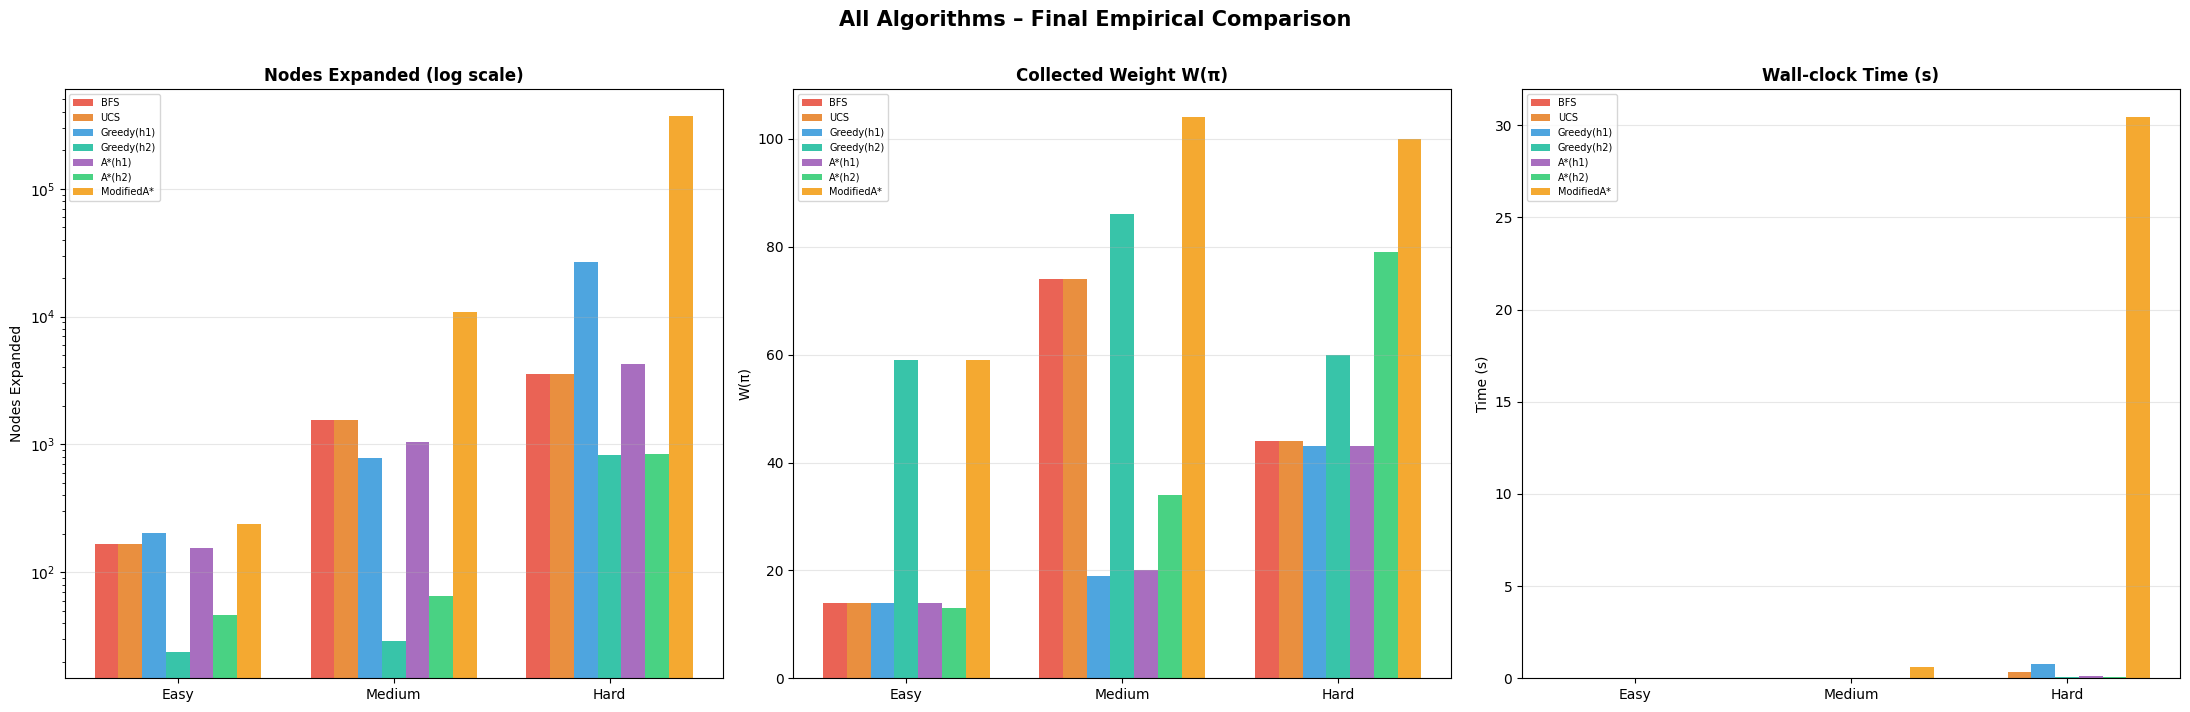

In [54]:
difficulties = ['Easy', 'Medium', 'Hard']
algos  = ['BFS', 'UCS', 'Greedy(h1)', 'Greedy(h2)', 'A*(h1)', 'A*(h2)', 'ModifiedA*']
colors = ['#E74C3C', '#E67E22', '#3498DB', '#1ABC9C',
          '#9B59B6', '#2ECC71', '#F39C12']

all_results = {
    'BFS':        [bfs_easy,        bfs_medium,        bfs_hard],
    'UCS':        [ucs_easy,        ucs_medium,        ucs_hard],
    'Greedy(h1)': [greedy_h1_easy,  greedy_h1_medium,  greedy_h1_hard],
    'Greedy(h2)': [greedy_h2_easy,  greedy_h2_medium,  greedy_h2_hard],
    'A*(h1)':     [astar_h1_easy,   astar_h1_medium,   astar_h1_hard],
    'A*(h2)':     [astar_h2_easy,   astar_h2_medium,   astar_h2_hard],
    'ModifiedA*': [mAstar_easy,     mAstar_medium,     mAstar_hard],
}

expanded_data = {a: [r.nodes_expanded  for r in rs] for a, rs in all_results.items()}
weight_data   = {a: [r.collected_weight for r in rs] for a, rs in all_results.items()}
time_data     = {a: [r.time_sec         for r in rs] for a, rs in all_results.items()}

x     = np.arange(len(difficulties))
width = 0.11

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Nodes Expanded ──────────────────────────────────────────────────────────
ax = axes[0]
for i, (algo, color) in enumerate(zip(algos, colors)):
    ax.bar(x + i*width, expanded_data[algo], width,
           label=algo, color=color, alpha=0.87)
ax.set_title('Nodes Expanded (log scale)', fontsize=12, fontweight='bold')
ax.set_xticks(x + 3*width); ax.set_xticklabels(difficulties)
ax.set_ylabel('Nodes Expanded'); ax.set_yscale('log')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

# ── Collected Weight ────────────────────────────────────────────────────────
ax = axes[1]
for i, (algo, color) in enumerate(zip(algos, colors)):
    ax.bar(x + i*width, weight_data[algo], width,
           label=algo, color=color, alpha=0.87)
ax.set_title('Collected Weight W(π)', fontsize=12, fontweight='bold')
ax.set_xticks(x + 3*width); ax.set_xticklabels(difficulties)
ax.set_ylabel('W(π)'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

# ── Wall-clock Time ─────────────────────────────────────────────────────────
ax = axes[2]
for i, (algo, color) in enumerate(zip(algos, colors)):
    ax.bar(x + i*width, time_data[algo], width,
           label=algo, color=color, alpha=0.87)
ax.set_title('Wall-clock Time (s)', fontsize=12, fontweight='bold')
ax.set_xticks(x + 3*width); ax.set_xticklabels(difficulties)
ax.set_ylabel('Time (s)'); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

plt.suptitle('All Algorithms – Final Empirical Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### D2 Validation: Theoretical vs Empirical

Here we compare what D2 predicted against what we actually observed.

In [56]:
print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║              D2 THEORETICAL vs D3 EMPIRICAL VALIDATION                    ║
╠══════════════════╦═══════════════════════════╦════════════════════════════╣
║ Algorithm        ║ D2 Predicted              ║ D3 Observed                ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ BFS              ║ Complete & Not optimal    ║ Confirmed - fewest moves,  ║
║                  ║ O(b^d) time & space       ║ not max weight             ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ UCS              ║ Complete & Not optimal    ║ Confirmed - same path as   ║
║                  ║ O(b^d) time & space       ║ BFS (uniform costs)        ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ Greedy(h1/h2)    ║ Complete & Not optimal    ║ Confirmed - fast but       ║
║                  ║ h2 expands fewer nodes    ║ suboptimal weight          ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ A*(h1)           ║ Complete & Not optimal    ║ Confirmed - min moves,     ║
║                  ║ O(b^d) worst case         ║ not max weight             ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ A*(h2)           ║ Fewer expansions than h1  ║ Confirmed - h2 dominance   ║
║                  ║ due to h2 dominance       ║ reduces node count         ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ Modified A*      ║ Complete & Optimal        ║ Confirmed - highest W(π)   ║
║                  ║ B&B pruning reduces work  ║ among all algorithms       ║
╚══════════════════╩═══════════════════════════╩════════════════════════════╝

Node count vs complexity analysis:
  • BFS/UCS expand the most nodes - consistent with O(b^d) blind search
  • Greedy expands far fewer - heuristic guidance prunes heavily
  • A*(h2) < A*(h1) in expansions - confirms h2 dominance theorem
  • Modified A* may expand more than standard A* in some cases because
    it cannot stop at first goal - it must exhaust all promising branches.
    However, B&B pruning (F(s) <= best) significantly reduces the search
    space compared to an exhaustive approach.
""")


╔═══════════════════════════════════════════════════════════════════════════╗
║              D2 THEORETICAL vs D3 EMPIRICAL VALIDATION                    ║
╠══════════════════╦═══════════════════════════╦════════════════════════════╣
║ Algorithm        ║ D2 Predicted              ║ D3 Observed                ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ BFS              ║ Complete & Not optimal    ║ Confirmed - fewest moves,  ║
║                  ║ O(b^d) time & space       ║ not max weight             ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ UCS              ║ Complete & Not optimal    ║ Confirmed - same path as   ║
║                  ║ O(b^d) time & space       ║ BFS (uniform costs)        ║
╠══════════════════╬═══════════════════════════╬════════════════════════════╣
║ Greedy(h1/h2)    ║ Complete & Not optimal    ║ Confirmed - fast but       ║
║                  ║ h2 expands fewer nodes    ║ suboptimal wei

### Modified A* – Key Observations

- Modified A* is the **only algorithm that is optimal for the max-weight objective** `W(π)`. All others either find the shortest path or a heuristically guided path — none guarantee maximum weight.
- The key shift: frontier ordered by **`-F(s) = -(G(s) + U(s))`** (max-heap), compared to standard A*'s min-heap on `g + h`.
- **`U(s)` is a relaxed upper bound** — it ignores obstacles and inter-item travel costs, so it may overestimate. This is intentional and required: overestimating is safe for B&B pruning (we only prune when `F(s) ≤ best`, so we never prune a path that could be optimal).
- **Modified A* does not stop at the first goal** — it records the best goal found and continues until no frontier node can possibly improve it. This is the core difference from standard A*, and is why it expands more nodes.
- **Critical fix — lazy-deletion at expansion time, not generation time**: `best_G[state]` is written when a node is *popped*, not when it is *pushed*. If it were written at push time, a worse path generated first would lock out a better path generated later for the same state, causing the algorithm to either return a suboptimal result or hit the node cap prematurely with `W(π) = 0`.
- The `max_nodes` cap is set higher than other algorithms (2M vs 500K) because Modified A* must exhaust all promising branches to prove optimality — it cannot terminate early the way goal-directed algorithms can.
- In practice, strong B&B pruning (discarding any node with `F(s) ≤ best`) significantly reduces the effective search space once a good solution is found early.